# 1. What is a Neural Network?

A Neural Network (NN) is a machine-learning model inspired by the way biological neurons process information.

A neural network learns a relationship between:

* Input → Hidden Layers → Output

For example, to predict whether a customer will leave:

2. Main Components of Neural Networks

## Input Layer

### Receives features.

### Example:

* Age
* Salary
* Experience

### If there are 3 features:

Input neurons = 3

### Hidden Layers

#######  These learn patterns.

########  Example:

### Output Layer

* Depends on the problem.

#### Binary classification

#### Example:

* Disease = Yes / No

#### Usually:

* Dense(1, activation="sigmoid")
* Multiclass classification

#### Example:

* Cat
* Dog
* Horse

### Usually:

* Dense(3, activation="softmax")
* Regression

### Example:

#### House Price

* Usually:

* Dense(1)

# 3. Important Neural Network Types

* There are many types of neural networks.

# 1. ANN / Feedforward Neural Network

* Artificial Neural Network.

### Used for:

* Classification
* Regression
* Tabular data

#### Architecture:

# 2. CNN — Convolutional Neural Network

* Primarily used for:

* Images
* Computer vision
* Image classification
* Object detection

#### Architecture:

# 3. RNN — Recurrent Neural Network

* Designed for sequential data.

* Used for:

* Time series
* Text
* Sequential information

# 4. LSTM

* Long Short-Term Memory.

####  An improved type of RNN that handles longer dependencies.

* Used for:

* Time series
* NLP
* Sequence prediction

# 5. GRU

* Gated Recurrent Unit.

##### Similar to LSTM but generally simpler.

6. Autoencoder

Used for:

* Dimensionality reduction
* Anomaly detection
* Data compression
* Representation learning

Architecture:

# 7. GAN

Generative Adversarial Network.

##### Contains:

# 8. Transformer

Modern architecture widely used in:

* NLP
* Text generation
* Translation
* Large language models
* Vision and multimodal tasks

Examples include transformer-based language models and BERT-style models.

# 4. Activation Functions

Activation functions help neural networks learn nonlinear relationships.

### ReLU

Most commonly used in hidden layers.

In [2]:
# activation="relu

## Conceptually:

* negative → 0
* positive → same value

## Sigmoid

* Output between 0 and 1.

* activation="sigmoid"

##### Good for binary classification.

* 0.2 → Class 0
* 0.8 → Class 1

### Softmax

* Used for multiclass classification.

activation="softmax"

# Tanh

* Output between -1 and 1.

* activation="tanh"

### Common in some recurrent architectures.

# 5. Loss Functions

Loss tells us how wrong the prediction is.

* Binary classification

## Binary classification

* loss="binary_crossentropy"

# Multiclass classification

* loss="sparse_categorical_crossentropy"

# or

* loss="categorical_crossentropy"

###### depending on target representation.

### Regression

* loss="mse"

# 6. Optimizers

Optimizers update model weights.

* Common optimizers:

* SGD
* Adam
* RMSprop
* Adagrad

A common beginner choice:


* optimizer="adam"

# 7. Epoch, Batch Size and Learning Rate
   * Epoch

One complete pass through the training dataset.

epochs=50

means the model can train through the dataset 50 times.



# Batch size

Number of samples processed before a weight update.

batch_size=32

# Learning rate

Controls how large the weight updates are.

* Conceptually:

* small learning rate
* → slower learning

* large learning rate
* → potentially unstable learning

# 8. Complete Neural Network ML Workflow

For a normal tabular classification project:

# 9. Libraries

For this tutorial we'll use TensorFlow/Keras.

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

### Install if necessary:

* pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

### Example 1 — Neural Network for Binary Classification
##### Problem Statement

* Predict whether a student will pass or fail based on:

* Study Hours
* Attendance
* Previous Score

# Step 1 — Create Dataset

In [4]:
import pandas as pd

data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9, 1, 2,
                    4, 6, 7, 8, 9, 3, 5, 6, 7, 8],

    "Attendance": [55, 60, 65, 70, 75, 80, 85, 90, 50, 58,
                   68, 76, 82, 88, 95, 62, 72, 78, 84, 91],

    "Previous_Score": [40, 45, 50, 55, 60, 65, 70, 80, 35, 42,
                       52, 62, 68, 75, 85, 48, 58, 64, 72, 82],

    "Pass": [0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
             0, 1, 1, 1, 1, 0, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

print(df.head())

   Study_Hours  Attendance  Previous_Score  Pass
0            2          55              40     0
1            3          60              45     0
2            4          65              50     0
3            5          70              55     1
4            6          75              60     1


# Step 2 — Understand Dataset

In [5]:
print(df.shape)

(20, 4)


Check rows and columns.

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     20 non-null     int64
 1   Attendance      20 non-null     int64
 2   Previous_Score  20 non-null     int64
 3   Pass            20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None


Check data types and missing values.

In [7]:
print(df.describe())

       Study_Hours  Attendance  Previous_Score      Pass
count    20.000000   20.000000       20.000000  20.00000
mean      5.500000   74.200000       60.400000   0.65000
std       2.438723   12.963918       14.500091   0.48936
min       1.000000   50.000000       35.000000   0.00000
25%       3.750000   64.250000       49.500000   0.00000
50%       6.000000   75.500000       61.000000   1.00000
75%       7.250000   84.250000       70.500000   1.00000
max       9.000000   95.000000       85.000000   1.00000


Check statistical information.

In [8]:
print(df.isnull().sum())

Study_Hours       0
Attendance        0
Previous_Score    0
Pass              0
dtype: int64


Check missing values.

# Step 3 — EDA

Check target distribution:

In [9]:
print(df["Pass"].value_counts())

Pass
1    13
0     7
Name: count, dtype: int64


# Step 4 — Visualization

Study hours versus previous score:

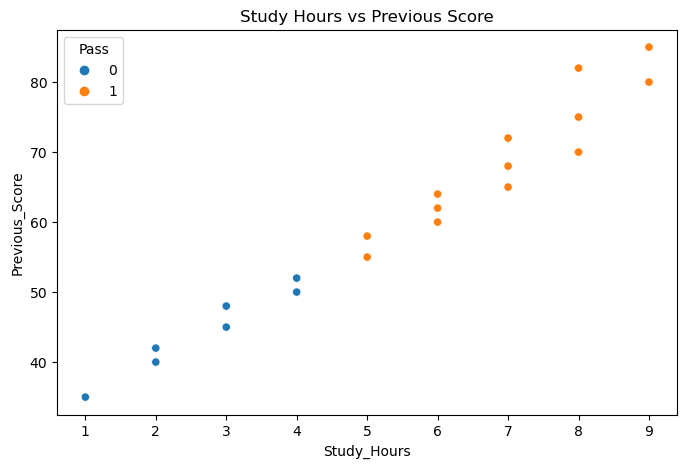

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Previous_Score",
    hue="Pass"
)

plt.title("Study Hours vs Previous Score")
plt.show()

Correlation:

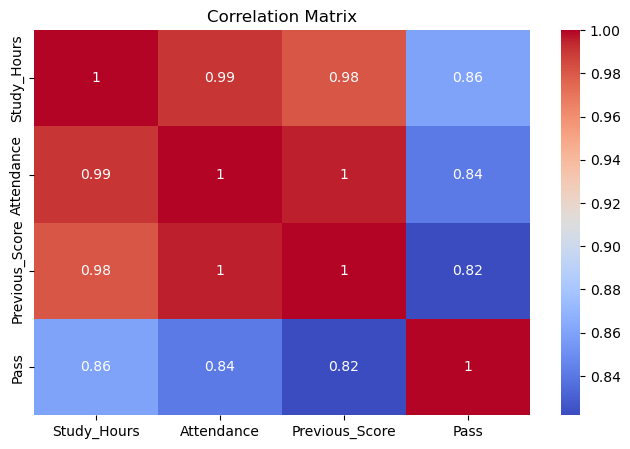

In [11]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Step 5 — X and y

In [12]:
X = df[[
    "Study_Hours",
    "Attendance",
    "Previous_Score"
]]

y = df["Pass"]

# Here:

* X = input features
* y = target

# Step 6 — Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### We use:

* 80% → training
* 20% → testing

stratify=y helps preserve the class distribution between train and test sets.

# Step 7 — Feature Scaling

Neural networks generally benefit from appropriately scaled numerical features.

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Important

Do:

scaler.fit_transform(X_train)

and:

scaler.transform(X_test)

Do not fit the scaler separately on the test data, because that leaks information from the test set into preprocessing.

In [15]:
scaler.fit_transform(X_train)



array([[-0.08161943, -0.19894076, -0.23415672],
       [-0.51692308, -0.3621742 , -0.45894718],
       [ 0.35368422,  0.29075957,  0.29035434],
       [ 0.35368422,  0.45399301,  0.44021464],
       [ 1.22429151,  1.02531005,  0.88979555],
       [ 1.65959516,  1.84147726,  2.01374782],
       [ 0.78898786,  0.94369333,  1.03965585],
       [-0.51692308, -0.60702436, -0.60880748],
       [-1.38753038, -1.42319156, -1.35810899],
       [-0.08161943, -0.03570732, -0.00936627],
       [ 0.78898786,  0.61722645,  0.51514479],
       [-1.82283403, -1.83127517, -1.73275975],
       [ 1.22429151,  1.27016021,  1.26444631],
       [ 0.35368422,  0.20914285,  0.14049403],
       [-0.95222673, -1.01510796, -0.98345824],
       [-1.38753038, -1.1783414 , -1.20824869]])

and:



In [16]:
scaler.transform(X_test)



array([[ 0.78898786,  0.78045989,  0.73993525],
       [-0.95222673, -0.85187452, -0.75866778],
       [ 1.22429151,  1.51501037,  1.78895736],
       [ 1.65959516,  1.43339365,  1.63909706]])

Do not fit the scaler separately on the test data, because that leaks information from the test set into preprocessing.

# Step 8 — Build Neural Network

In [17]:
model = Sequential([
    
    Dense(
        16,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

c:\Users\ipcs nagpur\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 9 — Compile Model

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Why?

#### optimizer
* optimizer="adam"
* Updates the weights.

#### loss
* loss="binary_crossentropy"
* Suitable for binary classification.

#### metrics
* metrics=["accuracy"]
* Measures classification accuracy.

# Step 10 — Train Model

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - accuracy: 0.3229 - loss: 0.9480 - val_accuracy: 0.5000 - val_loss: 0.8156
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3229 - loss: 0.8387 - val_accuracy: 0.5000 - val_loss: 0.7976
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3542 - loss: 0.7867 - val_accuracy: 0.5000 - val_loss: 0.7804
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2604 - loss: 0.8788 - val_accuracy: 0.5000 - val_loss: 0.7632
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3854 - loss: 0.7397 - val_accuracy: 0.5000 - val_loss: 0.7469
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2917 - loss: 0.7724 - val_accuracy: 0.5000 - val_loss: 0.7310
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3229 - loss: 0.7958 - val_accuracy: 0.5000 - val_loss: 0.7152
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3646 - loss: 0.7888 - val_accuracy: 0.5000 - val_loss: 0.699

### Here:

* epochs = 50
* batch_size = 4
* validation_split = 20%

The validation set helps monitor performance on data not directly used for weight updates.

## Step 11 — Visualize Training
* Accuracy

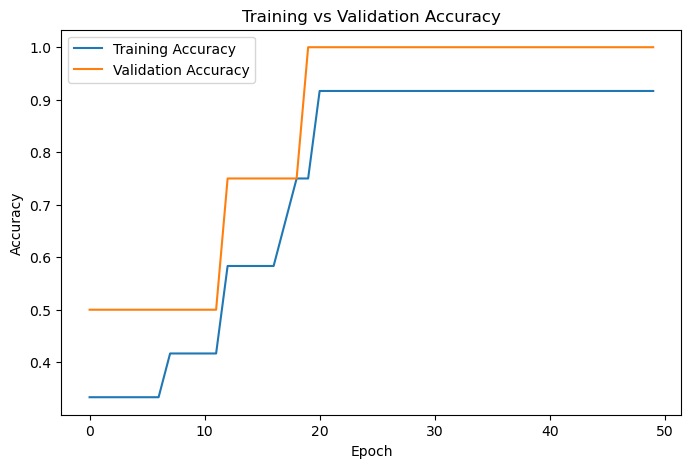

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

# Loss

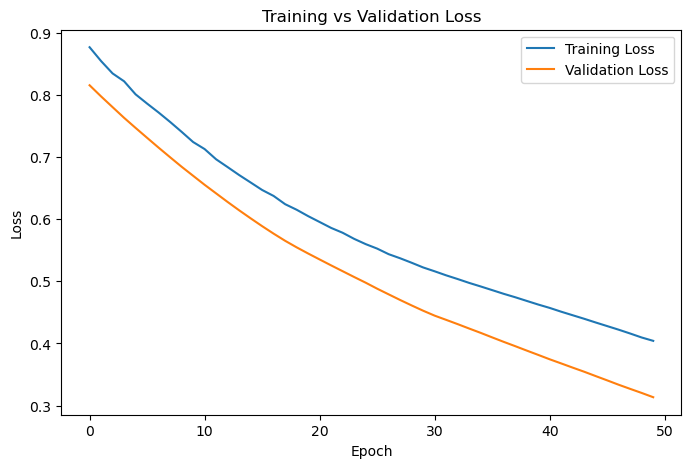

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

### You are looking for patterns such as:

* Training loss ↓
* Validation loss ↓

### which generally indicates learning.

If training loss keeps decreasing while validation loss starts increasing, that can indicate overfitting.

# Step 12 — Evaluate Model

In [22]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 1.0000 - loss: 0.3164
Test Loss: 0.316378653049469
Test Accuracy: 1.0


# Step 13 — Prediction

In [23]:
y_probability = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


In [24]:
y_pred = (y_probability >= 0.5).astype(int)

# Step 14 — Classification Report

In [25]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Step 15 — Confusion Matrix

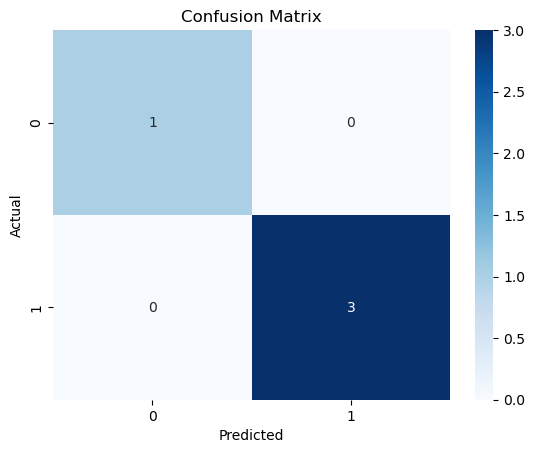

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Example 2 — Neural Network Regression

# Problem

### Predict house price from:

* Area
* Bedrooms
* Bathrooms
* Age

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create Dataset 

In [2]:


data = {
    "Area": [800, 1000, 1200, 1500, 1800,
             2000, 2200, 2500, 2800, 3000],

    "Bedrooms": [2, 2, 3, 3, 3,
                 4, 4, 4, 5, 5],

    "Bathrooms": [1, 2, 2, 2, 3,
                  3, 3, 4, 4, 4],

    "Age": [20, 18, 15, 12, 10,
            8, 7, 5, 3, 2],

    "Price": [40, 50, 60, 75, 90,
              105, 120, 140, 165, 180]
}

df = pd.DataFrame(data)

# Separate X/y:

In [3]:
X = df[
    [
        "Area",
        "Bedrooms",
        "Bathrooms",
        "Age"
    ]
]

y = df["Price"]

# Split:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale:

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model:

In [6]:
model = Sequential([
    Dense(32, activation="relu",
          input_shape=(X_train.shape[1],)),

    Dense(16, activation="relu"),

    Dense(8, activation="relu"),

    Dense(1)
])

c:\Users\ipcs nagpur\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


There is no sigmoid, because this is regression.

Compile:

In [7]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

Train:

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 553ms/step - loss: 13462.0439 - mae: 104.2890 - val_loss: 10092.8145 - val_mae: 97.9043
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 10646.3057 - mae: 93.6407 - val_loss: 10084.0537 - val_mae: 97.8621
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 14209.0400 - mae: 109.4812 - val_loss: 10074.8828 - val_mae: 97.8170
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 13946.7979 - mae: 108.1562 - val_loss: 10065.8105 - val_mae: 97.7720
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 13765.9453 - mae: 106.4642 - val_loss: 10055.3584 - val_mae: 97.7204
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 14160.4092 - mae: 109.2759 - val_loss: 10044.5879 - val_mae: 97.6669
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 11930.6270 - mae: 100.0146 - val_loss: 10034.1904 - val_mae: 97.6148
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 12376.7666 - mae: 99.5649 - val_loss: 10025.021

Predict:

In [9]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step


Evaluate:

In [10]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 7312.1851 - mae: 69.0035
MAE: 69.00347137451172


# Example 3 — Multiclass Classification
### Problem

* Predict flower species.

#### Classes:

* Setosa
* Versicolor
* Virginica

We'll use the Iris dataset.

In [11]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target



Split:

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scale:

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Build:

In [14]:
model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(4,)
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )
])

c:\Users\ipcs nagpur\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Why:

Dense(3, activation="softmax")

Because there are three classes.

Compile:

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train:

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.3109 - loss: 1.1197 - val_accuracy: 0.5833 - val_loss: 1.0872
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4658 - loss: 1.0428 - val_accuracy: 0.3750 - val_loss: 1.0398
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4732 - loss: 1.0160 - val_accuracy: 0.4167 - val_loss: 0.9934
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6220 - loss: 0.9396 - val_accuracy: 0.4167 - val_loss: 0.9487
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6542 - loss: 0.8827 - val_accuracy: 0.4583 - val_loss: 0.8994
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7115 - loss: 0.8312 - val_accuracy: 0.5417 - val_loss: 0.8445
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7751 - loss: 0.7806 - val_accuracy: 0.6250 - val_loss: 0.7875
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8445 - loss: 0.6986 - val_accuracy: 0.6250 - val_loss: 0.7356

Predict:

In [17]:
probabilities = model.predict(X_test)

y_pred = np.argmax(
    probabilities,
    axis=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


Evaluate:

In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

NameError: name 'classification_report' is not defined

# Example 4 — Neural Network for Image Classification

For image problems, we commonly use CNNs rather than a basic dense ANN.

We'll use MNIST.

In [19]:
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

Load data:

In [20]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

MNIST images are 28 × 28 grayscale images.

# Normalize:

In [21]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Add channel dimension:

In [22]:
X_train = X_train.reshape(
    -1, 28, 28, 1
)

X_test = X_test.reshape(
    -1, 28, 28, 1
)

Build CNN:

In [23]:
model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )
])

c:\Users\ipcs nagpur\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Architecture:

Compile:

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train:

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.8276 - loss: 0.5435 - val_accuracy: 0.9828 - val_loss: 0.0594
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.9717 - loss: 0.0879 - val_accuracy: 0.9880 - val_loss: 0.0432
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9799 - loss: 0.0699 - val_accuracy: 0.9892 - val_loss: 0.0392
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9830 - loss: 0.0558 - val_accuracy: 0.9912 - val_loss: 0.0365
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.9868 - loss: 0.0441 - val_accuracy: 0.9918 - val_loss: 0.0314



Evaluate:

In [26]:
model.evaluate(
    X_test,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9882 - loss: 0.0337


[0.02641969919204712, 0.9914000034332275]

# Example 5 — RNN for Time-Series Prediction

Suppose we want to predict a future value based on previous values.

# Example:

* Day 1 → 100
* Day 2 → 105
* Day 3 → 110
* Day 4 → 108
* Day 5 → ?

An RNN can process the sequence.

In [27]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

Create sample sequence:

In [28]:
data = np.array([
    [100],
    [105],
    [110],
    [115],
    [120],
    [125],
    [130],
    [135],
    [140],
    [145]
], dtype=float)

Create sequences:

In [29]:
X = []
y = []

window = 3

for i in range(len(data) - window):

    X.append(
        data[i:i+window]
    )

    y.append(
        data[i+window]
    )

X = np.array(X)
y = np.array(y)

In [31]:
model = Sequential([

    SimpleRNN(
        32,
        activation="tanh",
        input_shape=(3, 1)
    ),

    Dense(1)
])

c:\Users\ipcs nagpur\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile:

In [32]:
model.compile(
    optimizer="adam",
    loss="mse"
)

Train:

In [33]:
model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

Predict:

In [34]:
prediction = model.predict(
    np.array([
        [
            [135],
            [140],
            [145]
        ]
    ])
)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[2.395689]]


This demonstrates the basic idea of using a recurrent architecture for sequential data.

# 10. ANN vs CNN vs RNN vs LSTM vs GRU

| Type        | Common use                                        |
| ----------- | ------------------------------------------------- |
| ANN         | Tabular data                                      |
| CNN         | Images / spatial data                             |
| RNN         | Sequential data                                   |
| LSTM        | Long sequence dependencies                        |
| GRU         | Sequential data with a simpler gated architecture |
| Autoencoder | Representation/compression/anomaly detection      |
| GAN         | Generative modeling                               |
| Transformer | NLP, sequences, multimodal AI                     |


# 11. Neural Network Overfitting

#### A common problem is:

* Training performance → very good
* Validation performance → gets worse

#### Possible solutions:

* Dropout

In [35]:
from tensorflow.keras.layers import Dropout

Dropout(0.3)

<Dropout name=dropout_1, built=False>

Example:

In [36]:
model = Sequential([
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

Early Stopping

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

Use it:

In [39]:
# history = model.fit(
#     X_train,
#     y_train,
#     epochs=100,
#     validation_split=0.2,
#     callbacks=[early_stop]
# )

Instead of blindly training all 100 epochs, training can stop when validation performance stops improving.

# 12. Better Neural Network Workflow

For your ML projects, remember this structure:

# 13. Save Neural Network


model.save("neural_network_model.keras")

Save scaler:

# 14. New Data Prediction

# 15. What You Should Learn Next

Since you're building your ML skills step-by-step, I recommend learning Neural Networks in this order:

The 5 practice projects above give you five different situations:
* ANN → Binary Classification — Student Pass/Fail
* ANN → Regression — House Price Prediction
* ANN → Multiclass Classification — Iris Classification
* CNN → Image Classification — MNIST
* RNN → Sequence Prediction — Time Series

The most important next step is to take one real dataset and implement the entire workflow—data cleaning → EDA → visualization → preprocessing → train/test split → neural network → training/validation → evaluation → hyperparameter tuning → saving → new prediction → deployment—as a single end-to-end project.